In [1]:
import os
import pandas as pd
import kagglehub
import os

print(os.listdir("/kaggle/input"))

path = '/kaggle/input/datasets/adityajanjiree/bone-cancer'
dataset_path = os.path.join(path, "BTXRD")

# path
images_path = os.path.join(dataset_path, "images")
excel_path = os.path.join(dataset_path, "dataset.xlsx")

# load data
df = pd.read_excel(excel_path)

print("Total data awal:", len(df))

# filter lower limb
df = df[df["lower limb"] == 1].copy()

print("Total data lower limb:", len(df))
print(df.head())

['datasets']
Total data awal: 3746
Total data lower limb: 2406
         image_id  center  age gender  hand  ulna  radius  humerus  foot  \
1  IMG000002.jpeg       1   12      M     0     0       0        0     0   
2  IMG000003.jpeg       1   12      M     0     0       0        0     0   
3  IMG000004.jpeg       1   52      M     0     0       0        0     1   
4  IMG000005.jpeg       1   52      M     0     0       0        0     1   
5  IMG000006.jpeg       1   62      M     0     0       0        0     0   

   tibia  ...  synovial osteochondroma  other bt  osteosarcoma  other mt  \
1      1  ...                        0         0             1         0   
2      1  ...                        0         0             1         0   
3      0  ...                        0         0             1         0   
4      0  ...                        0         0             1         0   
5      0  ...                        0         0             1         0   

   upper limb  lower li

In [2]:
# buat label baru
def map_label(row):
    if row["malignant"] == 1:
        return "malignant"
    elif row["benign"] == 1:
        return "benign"
    else:
        return "normal"

df["label"] = df.apply(map_label, axis=1)

# cek distribusi
print("\nDistribusi kelas:")
print(df["label"].value_counts())


Distribusi kelas:
label
normal       1095
benign       1081
malignant     230
Name: count, dtype: int64


In [3]:
# buat path gambar
df["image_path"] = df["image_id"].apply(
    lambda x: os.path.join(images_path, x)
)

# dataframe final
df_model = df[["image_path", "label"]].copy()

print("\nContoh data:")
print(df_model.head())


Contoh data:
                                          image_path      label
1  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant
2  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant
3  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant
4  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant
5  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant


In [4]:
# SPLIT DATA ======================================================
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_model,
    test_size=0.2,
    stratify=df_model["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nDistribusi train:")
print(train_df["label"].value_counts())

Train: 1924
Validation: 241
Test: 241

Distribusi train:
label
normal       876
benign       864
malignant    184
Name: count, dtype: int64


2026-06-07 01:07:44.803178: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780794465.018459      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780794465.083680      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780794465.595026      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780794465.595076      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780794465.595080      57 computation_placer.cc:177] computation placer alr

Mulai pipeline FINAL...
Class weight: {0: np.float64(0.7422839506172839), 1: np.float64(3.4855072463768115), 2: np.float64(0.7321156773211568)}

Menampilkan semua tahap preprocessing...


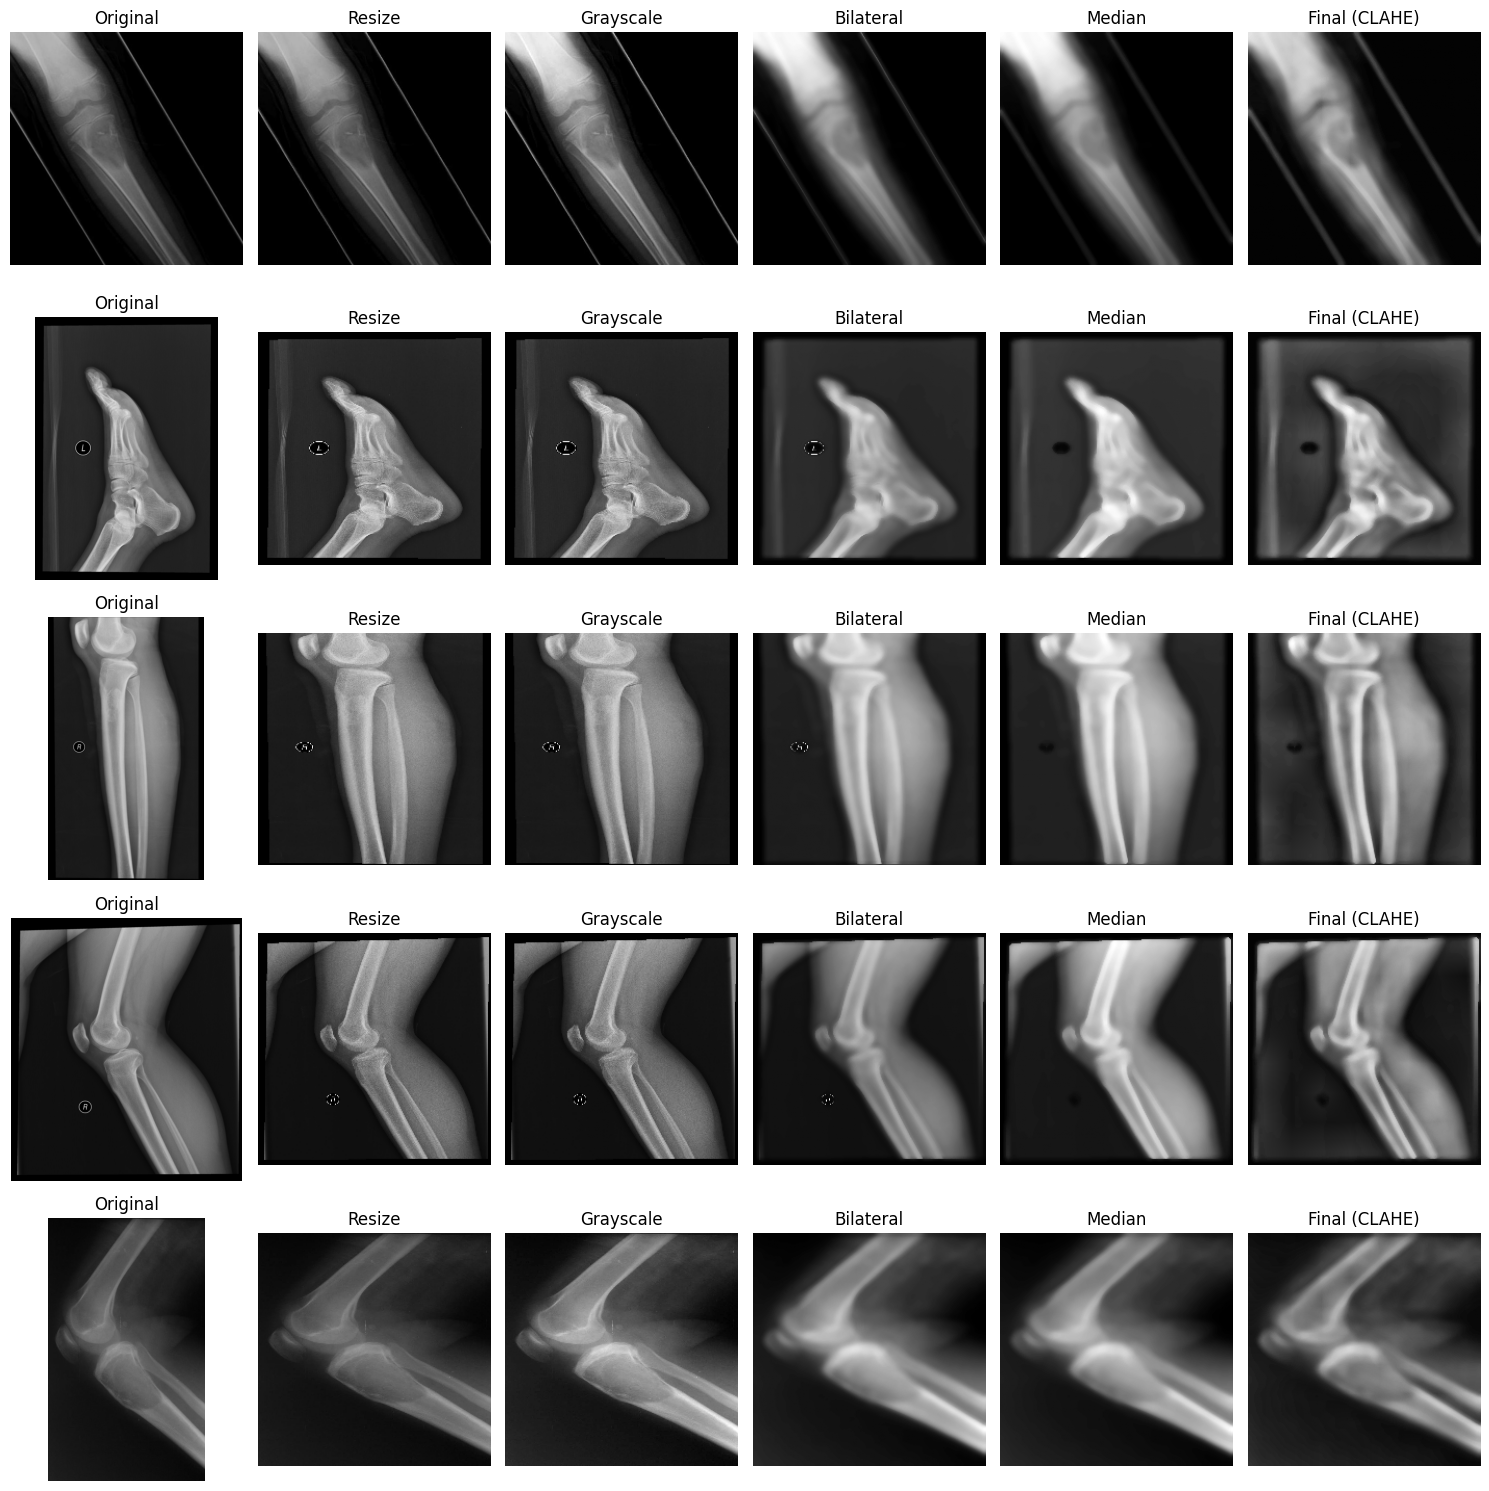


Batch info:
Train: 61
Val  : 8
Test : 8


2026-06-07 01:08:12.556548: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.3917 - loss: 1.2581 - val_accuracy: 0.4025 - val_loss: 1.1158 - learning_rate: 5.0000e-05
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.3964 - loss: 1.1650 - val_accuracy: 0.4896 - val_loss: 1.0464 - learning_rate: 5.0000e-05
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.4619 - loss: 1.0340 - val_accuracy: 0.5270 - val_loss: 1.0055 - learning_rate: 5.0000e-05
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.4847 - loss: 0.9913 - val_accuracy: 0.5353 - val_loss: 0.9681 - learning_rate: 5.0000e-05
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.5539 - loss: 0.9626 - val_accuracy: 0.5726 - val_loss: 0.9495 - learning_rate: 5.0000e-05
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.5592 - loss: 0.9466 - val_accuracy: 0.5892 - val_loss: 0.9408 - learning_rate: 5.0000e-05
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.5851 - loss

In [5]:
# =========================================
# FINAL PIPELINE: PREVIEW + AUGMENT + OPTIMIZED MODEL
# =========================================

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import math

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

print("Mulai pipeline FINAL...")

# =========================================
# PREPROCESS FUNCTION (FILTER_CLAHE)
# =========================================

def preprocess_image(img):
    img = cv2.resize(img, (224,224))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    bilateral = cv2.bilateralFilter(gray, 9, 75, 75)
    median = cv2.medianBlur(bilateral, 5)

    clahe = cv2.createCLAHE(2.0, (8,8))
    processed = clahe.apply(median)

    processed = cv2.cvtColor(processed, cv2.COLOR_GRAY2RGB)
    processed = preprocess_input(
        processed.astype(np.float32))
    return processed


# =========================================
# VISUALISASI PREPROCESS (DEBUG)
# =========================================

def show_preprocessing_sample(df, n=3):
    print("\nMenampilkan semua tahap preprocessing...")

    fig, axes = plt.subplots(n, 6, figsize=(15, 3*n))

    for i in range(n):
        row = df.sample(1).iloc[0]
        img = cv2.imread(row["image_path"])

        if img is None:
            continue

        # STEP 1
        resized = cv2.resize(img, (224,224))

        # STEP 2
        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

        # STEP 3
        bilateral = cv2.bilateralFilter(gray, 9, 75, 75)

        # STEP 4
        median = cv2.medianBlur(bilateral, 5)

        # STEP 5
        clahe = cv2.createCLAHE(2.0, (8,8))
        clahe_img = clahe.apply(median)

        # STEP 6
        final = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB) / 255.0

        images = [
            cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
            resized,
            gray,
            bilateral,
            median,
            final
        ]

        titles = [
            "Original",
            "Resize",
            "Grayscale",
            "Bilateral",
            "Median",
            "Final (CLAHE)"
        ]

        for j in range(6):
            axes[i,j].imshow(images[j], cmap="gray" if j>=2 else None)
            axes[i,j].set_title(titles[j])
            axes[i,j].axis("off")

    plt.tight_layout()
    plt.show()
    
# =========================================
# GENERATOR (AUGMENT LEBIH KUAT)
# =========================================

class CustomGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(df))
        self.labels = sorted(df["label"].unique())
        self.label_map = {k:i for i,k in enumerate(self.labels)}

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, idx):
        batch_idx = self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]
        batch = self.df.iloc[batch_idx]

        X, y = [], []

        for _, row in batch.iterrows():
            img = cv2.imread(row["image_path"])
            if img is None:
                continue

            img = preprocess_image(img)

            # =================================
            # AUGMENTASI LEBIH KUAT (TRAIN ONLY)
            # =================================
            if self.shuffle:
                if np.random.rand() < 0.5:
                    img = np.fliplr(img)
                if np.random.rand() < 0.3:
                    angle = np.random.uniform(-10, 10)
                    M = cv2.getRotationMatrix2D(
                        (112,112),
                        angle,
                        1)
                
                    img = cv2.warpAffine(
                        img,
                        M,
                        (224,224))
                    img = np.expand_dims(img, axis=-1) if len(img.shape)==2 else img

                if np.random.rand() < 0.3:
                    noise = np.random.normal(0, 0.02, img.shape)
                    img = np.clip(img + noise, 0, 1)

                if np.random.rand() < 0.3:
                    img = np.clip(img * (0.8 + 0.4*np.random.rand()), 0, 1)

            X.append(img)
            y.append(self.label_map[row["label"]])

        return np.array(X), tf.keras.utils.to_categorical(y, num_classes=len(self.labels))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)


# =========================================
# MODEL OPTIMIZED
# =========================================

def build_model(num_classes):
    base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))

    # freeze lebih banyak
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    for layer in base_model.layers[-20:]:
        layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)

    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"])

    return model


# =========================================
# CLASS WEIGHT
# =========================================

labels = train_df["label"]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weight_dict = dict(zip(range(len(class_weights)), class_weights))

print("Class weight:", class_weight_dict)


# =========================================
# CALLBACK
# =========================================

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=1)


# =========================================
# PREVIEW HASIL PREPROCESS
# =========================================

show_preprocessing_sample(train_df, n=5)


# =========================================
# GENERATOR
# =========================================

train_gen = CustomGenerator(train_df, 32, shuffle=True)
val_gen = CustomGenerator(val_df, 32, shuffle=False)
test_gen = CustomGenerator(test_df, 32, shuffle=False)

print("\nBatch info:")
print("Train:", len(train_gen))
print("Val  :", len(val_gen))
print("Test :", len(test_gen))


# =========================================
# TRAINING FINAL
# =========================================

model = build_model(num_classes=len(train_gen.labels))

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


# =========================================
# EVALUASI
# =========================================

y_pred, y_true = [], []

for i in range(len(test_gen)):
    X, y = test_gen[i]

    if len(X) == 0:
        continue

    pred = model.predict(X, verbose=0)

    y_pred.extend(np.argmax(pred, axis=1))
    y_true.extend(np.argmax(y, axis=1))

print("\nAccuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

In [6]:
print(train_df["label"].value_counts())
print(val_df["label"].value_counts())
print(test_df["label"].value_counts())

label
normal       876
benign       864
malignant    184
Name: count, dtype: int64
label
normal       110
benign       108
malignant     23
Name: count, dtype: int64
label
normal       109
benign       109
malignant     23
Name: count, dtype: int64



FULL PREDICTION TABLE — ALL SAMPLES
       actual  predicted  confidence  correct  prob_benign  prob_malignant  \
0      benign     benign    0.350421     True     0.350421        0.341740   
1      benign  malignant    0.355311    False     0.298427        0.355311   
2      benign     benign    0.365965     True     0.365965        0.302418   
3      normal  malignant    0.369270    False     0.293162        0.369270   
4      normal     normal    0.372592     True     0.355847        0.271560   
5   malignant  malignant    0.374271     True     0.263782        0.374271   
6      benign     benign    0.382306     True     0.382306        0.258515   
7      normal     benign    0.383882    False     0.383882        0.331134   
8      normal  malignant    0.385172    False     0.305231        0.385172   
9      benign     benign    0.389245     True     0.389245        0.308933   
10     benign  malignant    0.396404    False     0.229768        0.396404   
11     normal     benign   

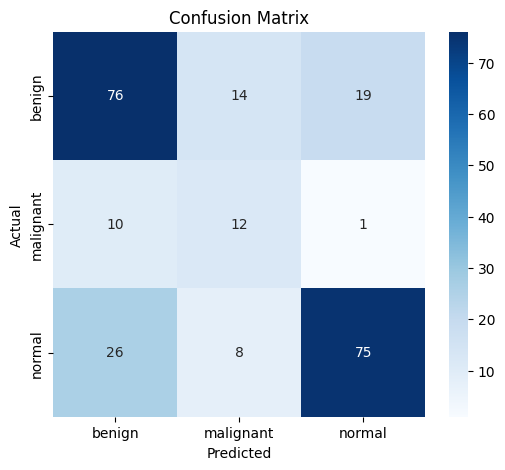

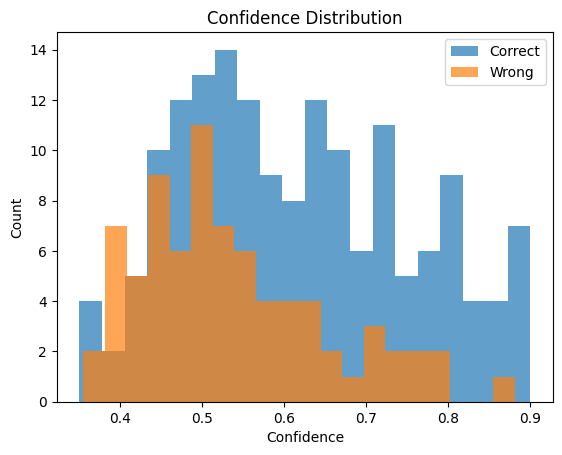

In [7]:
# =========================================
# FULL PREDICTION TABLE + ANALYSIS
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\n" + "="*70)
print("FULL PREDICTION TABLE — ALL SAMPLES")
print("="*70)

# =========================================
# LABEL MAPPING
# =========================================

label_names = train_gen.labels
idx_to_label = {i:label for i,label in enumerate(label_names)}

# =========================================
# BUILD PREDICTION TABLE
# =========================================

records = []

for i in range(len(test_gen)):
    X, y = test_gen[i]

    if len(X) == 0:
        continue

    preds = model.predict(X, verbose=0)

    for j in range(len(X)):
        true_idx = np.argmax(y[j])
        pred_idx = np.argmax(preds[j])

        record = {
            "image_path": test_df.iloc[i*test_gen.batch_size + j]["image_path"],
            "actual": idx_to_label[true_idx],
            "predicted": idx_to_label[pred_idx],
            "confidence": float(np.max(preds[j])),
            "correct": true_idx == pred_idx
        }

        # simpan probabilitas tiap kelas
        for k in range(len(label_names)):
            record[f"prob_{idx_to_label[k]}"] = float(preds[j][k])

        records.append(record)

pred_df = pd.DataFrame(records)

# =========================================
# SORT BY UNCERTAINTY (LOW CONFIDENCE)
# =========================================

pred_df = pred_df.sort_values("confidence", ascending=True).reset_index(drop=True)

# =========================================
# PRINT TABLE
# =========================================

display_df = pred_df[[
    "actual", "predicted", "confidence", "correct"
] + [col for col in pred_df.columns if "prob_" in col]]

print(display_df.head(30))  # tampilkan 30 teratas (paling susah)

# =========================================
# SUMMARY
# =========================================

acc = accuracy_score(pred_df["actual"], pred_df["predicted"])

print("\n" + "-"*50)
print(f"Total data     : {len(pred_df)}")
print(f"Accuracy       : {acc:.4f}")
print(f"Correct        : {pred_df['correct'].sum()}")
print(f"Wrong          : {(~pred_df['correct']).sum()}")

print("\nClassification Report:")
print(classification_report(pred_df["actual"], pred_df["predicted"]))

# =========================================
# CONFUSION MATRIX
# =========================================

plt.figure(figsize=(6,5))
cm = confusion_matrix(pred_df["actual"], pred_df["predicted"], labels=label_names)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================
# CONFIDENCE DISTRIBUTION
# =========================================

plt.figure()
plt.hist(pred_df[pred_df["correct"]]["confidence"], bins=20, alpha=0.7, label="Correct")
plt.hist(pred_df[~pred_df["correct"]]["confidence"], bins=20, alpha=0.7, label="Wrong")
plt.legend()
plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.show()

In [8]:
model.save("bone_cancer_mobilenetv2.h5")

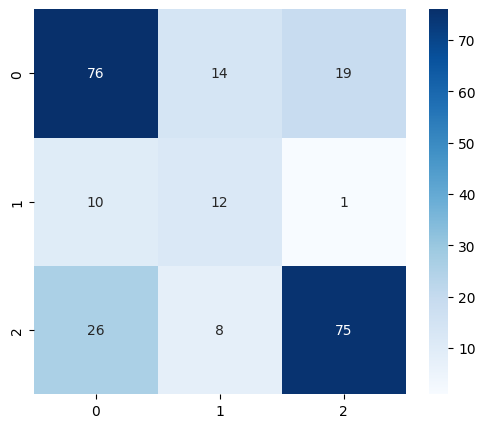

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.show()

In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 5,753,803 (21.95 MB)

 Trainable params: 1,567,299 (5.98 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 3,134,600 (11.96 MB)

In [11]:
# ==========================================
# MALIGNANT MISCLASSIFICATION ANALYSIS
# ==========================================

malignant_errors = pred_df[
    (pred_df["actual"] == "malignant") &
    (pred_df["predicted"] != "malignant")
]

print("Jumlah malignant salah prediksi:", len(malignant_errors))
display(malignant_errors.head())

print("\nDistribusi salah prediksi:")
print(malignant_errors["predicted"].value_counts())

Jumlah malignant salah prediksi: 11


,image_path,actual,predicted,confidence,correct,prob_benign,prob_malignant,prob_normal
13,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,benign,0.405914,False,0.405914,0.278875,0.315211
21,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,normal,0.422855,False,0.392642,0.184503,0.422855
22,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,benign,0.424478,False,0.424478,0.343266,0.232255
27,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,benign,0.437451,False,0.437451,0.167801,0.394748
35,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,benign,0.445806,False,0.445806,0.284462,0.269732



Distribusi salah prediksi:
predicted
benign    10
normal     1
Name: count, dtype: int64


In [12]:
# malignant yang salah diprediksi menjadi normal

malignant_to_normal = pred_df[
    (pred_df["actual"] == "malignant") &
    (pred_df["predicted"] == "normal")
]

print("Jumlah:", len(malignant_to_normal))

display(
    malignant_to_normal[
        ["image_path","confidence"]
    ].head(10)
)

Jumlah: 1


,image_path,confidence
21,/kaggle/input/datasets/adityajanjiree/bone-can...,0.422855


In [13]:
xai_samples = malignant_to_normal.nsmallest(
    3,
    "confidence"
)

xai_samples[[
    "image_path",
    "confidence"
]]

,image_path,confidence
21,/kaggle/input/datasets/adityajanjiree/bone-can...,0.422855


In [14]:
!pip install lime -q

In [15]:
sample_path = xai_samples.iloc[0]["image_path"]

print(sample_path)

/kaggle/input/datasets/adityajanjiree/bone-cancer/BTXRD/images/IMG001492.jpeg


In [16]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def lime_predict(images):

    processed = []

    for img in images:

        img = cv2.resize(img, (224,224))

        gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)

        bilateral = cv2.bilateralFilter(gray, 9, 75, 75)
        median = cv2.medianBlur(bilateral, 5)

        clahe = cv2.createCLAHE(2.0, (8,8))
        img2 = clahe.apply(median)

        img2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)

        img2 = preprocess_input(
            img2.astype(np.float32)
        )

        processed.append(img2)

    processed = np.array(processed)

    return model.predict(processed, verbose=0)

In [17]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

explanation = explainer.explain_instance(
    img,
    lime_predict,
    top_labels=3,
    hide_color=0,
    num_samples=250
)

  0%|          | 0/250 [00:00<?, ?it/s]

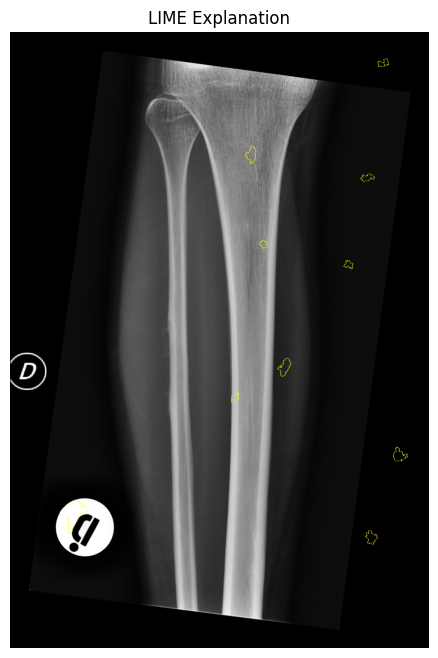

In [18]:
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

plt.figure(figsize=(8,8))
plt.imshow(mark_boundaries(temp/255.0, mask))
plt.title("LIME Explanation")
plt.axis("off")
plt.show()

In [19]:
xai_samples = malignant_errors.head(10)

print(xai_samples[
    ["actual","predicted","confidence"]
])

       actual predicted  confidence
13  malignant    benign    0.405914
21  malignant    normal    0.422855
22  malignant    benign    0.424478
27  malignant    benign    0.437451
35  malignant    benign    0.445806
36  malignant    benign    0.449553
62  malignant    benign    0.487210
65  malignant    benign    0.488631
72  malignant    benign    0.498392
74  malignant    benign    0.500600


In [20]:
!pip install shap -q

In [21]:
import shap

In [22]:
background = []

for i in range(20):
    img_path = train_df.iloc[i]["image_path"]

    img = cv2.imread(img_path)
    img = preprocess_image(img)

    background.append(img)

background = np.array(background)

In [23]:
sample_path = xai_samples.iloc[0]["image_path"]

img = cv2.imread(sample_path)
img = preprocess_image(img)

sample = np.expand_dims(img, axis=0)

In [24]:
explainer = shap.GradientExplainer(
    model,
    background
)

shap_values = explainer.shap_values(sample)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


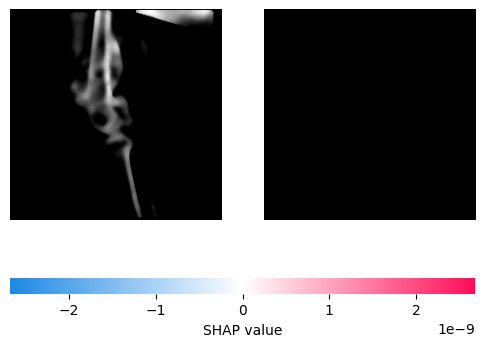

In [25]:
shap.image_plot(
    shap_values,
    sample
)

In [26]:
from sklearn.utils import resample

print(train_df["label"].value_counts())

label
normal       876
benign       864
malignant    184
Name: count, dtype: int64


In [27]:
max_count = train_df["label"].value_counts().max()

weighted_df = []

for cls in train_df["label"].unique():

    temp = train_df[
        train_df["label"] == cls
    ]

    temp = resample(
        temp,
        replace=True,
        n_samples=max_count,
        random_state=42
    )

    weighted_df.append(temp)

weighted_train_df = pd.concat(weighted_df)

weighted_train_df = weighted_train_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(weighted_train_df["label"].value_counts())

label
normal       876
benign       876
malignant    876
Name: count, dtype: int64


In [28]:
weighted_train_gen = CustomGenerator(
    weighted_train_df,
    batch_size=32,
    shuffle=True
)

In [29]:
model_ws = build_model(
    num_classes=len(train_gen.labels)
)

history_ws = model_ws.fit(
    weighted_train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.3697 - loss: 1.2176 - val_accuracy: 0.2946 - val_loss: 1.1962 - learning_rate: 5.0000e-05
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.5085 - loss: 1.0150 - val_accuracy: 0.3942 - val_loss: 1.1090 - learning_rate: 5.0000e-05
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.5824 - loss: 0.9388 - val_accuracy: 0.4523 - val_loss: 1.0683 - learning_rate: 5.0000e-05
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.6646 - loss: 0.8540 - val_accuracy: 0.6183 - val_loss: 0.9384 - learning_rate: 5.0000e-05
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.6964 - loss: 0.7908 - val_accuracy: 0.6100 - val_loss: 0.9422 - learning_rate: 5.0000e-05
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.7329 - loss: 0.7548 - val_accuracy: 0.6017 - val_loss: 0.9584 - learning_rate: 1.5000e-05


In [30]:
print(train_df["label"].value_counts())

label
normal       876
benign       864
malignant    184
Name: count, dtype: int64


In [31]:
malignant_df = train_df[
    train_df["label"]=="malignant"
]

malignant_over = malignant_df.sample(
    n=700,
    replace=True,
    random_state=42
)

train_over_df = pd.concat([
    train_df,
    malignant_over
])

train_over_df = train_over_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(train_over_df["label"].value_counts())

label
malignant    884
normal       876
benign       864
Name: count, dtype: int64


In [32]:
over_train_gen = CustomGenerator(
    train_over_df,
    batch_size=32,
    shuffle=True
)

In [33]:
model_over = build_model(
    num_classes=len(train_gen.labels)
)

history_over = model_over.fit(
    over_train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.3513 - loss: 1.2653 - val_accuracy: 0.3693 - val_loss: 1.1191 - learning_rate: 5.0000e-05
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.4873 - loss: 1.0278 - val_accuracy: 0.4481 - val_loss: 1.0478 - learning_rate: 5.0000e-05
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.5507 - loss: 0.9664 - val_accuracy: 0.5270 - val_loss: 1.0040 - learning_rate: 5.0000e-05
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.6315 - loss: 0.8753 - val_accuracy: 0.5726 - val_loss: 0.9384 - learning_rate: 5.0000e-05
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.6695 - loss: 0.8259 - val_accuracy: 0.5851 - val_loss: 0.9544 - learning_rate: 5.0000e-05
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.6975 - loss: 0.7869 - val_accuracy: 0.5975 - val_loss: 0.9402 - learning_rate: 1.5000e-05


In [34]:
class_counts = np.array([
    864,   # benign
    184,   # malignant
    876    # normal
])

print(class_counts)

[864 184 876]


In [35]:
print(train_gen.labels)
['benign','malignant','normal']

['benign', 'malignant', 'normal']


['benign', 'malignant', 'normal']

In [36]:
beta = 0.9999

effective_num = 1.0 - np.power(
    beta,
    class_counts
)

cb_weights = (
    (1-beta) / effective_num
)

cb_weights = cb_weights / np.sum(cb_weights)

print(cb_weights)

[0.15321189 0.69558563 0.15120248]


In [37]:
import tensorflow as tf

def cb_focal_loss(weights,
                  gamma=2.0):

    weights = tf.constant(
        weights,
        dtype=tf.float32
    )

    def loss(y_true, y_pred):

        y_pred = tf.clip_by_value(
            y_pred,
            1e-7,
            1.0
        )

        ce = -y_true * tf.math.log(y_pred)

        weight = y_true * weights

        focal = tf.pow(
            1-y_pred,
            gamma
        )

        loss_val = (
            weight *
            focal *
            ce
        )

        return tf.reduce_mean(
            tf.reduce_sum(
                loss_val,
                axis=1
            )
        )

    return loss

In [38]:
def build_cb_model(num_classes):

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    for layer in base_model.layers[:-20]:
        layer.trainable=False

    for layer in base_model.layers[-20:]:
        layer.trainable=True

    x = base_model.output

    x = GlobalAveragePooling2D()(x)

    x = Dense(
        256,
        activation='relu'
    )(x)

    x = Dropout(0.4)(x)

    x = Dense(
        128,
        activation='relu'
    )(x)

    x = Dropout(0.3)(x)

    output = Dense(
        num_classes,
        activation='softmax'
    )(x)

    model = Model(
        base_model.input,
        output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            5e-5
        ),
        loss=cb_focal_loss(
            cb_weights
        ),
        metrics=['accuracy']
    )

    return model

In [39]:
model_cb = build_cb_model(
    num_classes=len(train_gen.labels)
)

history_cb = model_cb.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.3766 - loss: 0.1476 - val_accuracy: 0.4855 - val_loss: 0.1124 - learning_rate: 5.0000e-05
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.3952 - loss: 0.1096 - val_accuracy: 0.5145 - val_loss: 0.1151 - learning_rate: 5.0000e-05
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.5003 - loss: 0.0942 - val_accuracy: 0.5228 - val_loss: 0.1086 - learning_rate: 1.5000e-05
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.4796 - loss: 0.0996 - val_accuracy: 0.5353 - val_loss: 0.1012 - learning_rate: 1.5000e-05
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.4738 - loss: 0.0922 - val_accuracy: 0.5477 - val_loss: 0.0976 - learning_rate: 1.5000e-05
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.4938 - loss: 0.0908 - val_accuracy: 0.5643 - val_loss: 0.0937 - learning_rate: 1.5000e-05
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.4814 - loss

In [40]:
import os

SAVE_DIR = "/kaggle/working/xai_bone_cancer"

os.makedirs(SAVE_DIR, exist_ok=True)

print(SAVE_DIR)

/kaggle/working/xai_bone_cancer


In [41]:
model_cb.save(
    f"{SAVE_DIR}/model_cb_focal.keras"
)

print("Model CB-Focal tersimpan")

Model CB-Focal tersimpan


In [42]:
import pandas as pd

history_df = pd.DataFrame(
    history_cb.history
)

history_df.to_csv(
    f"{SAVE_DIR}/history_cb_focal.csv",
    index=False
)

history_df.head()

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.378898,0.137295,0.485477,0.112378,0.000050
1,0.414761,0.106903,0.514523,0.115112,0.000050
2,0.475572,0.097617,0.522822,0.108591,0.000015
3,0.478170,0.098580,0.535270,0.101235,0.000015
4,0.466736,0.092591,0.547718,0.097591,0.000015


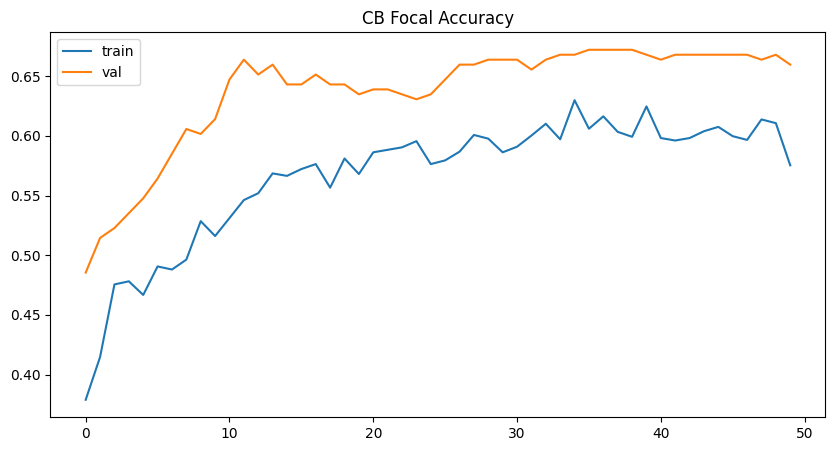

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history_cb.history["accuracy"],
    label="train"
)

plt.plot(
    history_cb.history["val_accuracy"],
    label="val"
)

plt.legend()
plt.title("CB Focal Accuracy")

plt.savefig(
    f"{SAVE_DIR}/cb_focal_accuracy.png",
    bbox_inches="tight"
)

plt.show()

In [44]:
from sklearn.metrics import classification_report

y_pred = []
y_true = []

for i in range(len(test_gen)):

    X, y = test_gen[i]

    pred = model_cb.predict(
        X,
        verbose=0
    )

    y_pred.extend(
        np.argmax(pred, axis=1)
    )

    y_true.extend(
        np.argmax(y, axis=1)
    )

In [45]:
report = classification_report(
    y_true,
    y_pred,
    target_names=train_gen.labels,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    f"{SAVE_DIR}/classification_report_cb_focal.csv"
)

report_df

,precision,recall,f1-score,support
benign,0.681319,0.568807,0.620000,109.000000
malignant,0.425000,0.739130,0.539683,23.000000
normal,0.718182,0.724771,0.721461,109.000000
accuracy,0.655602,0.655602,0.655602,0.655602
macro avg,0.608167,0.677569,0.627048,241.000000
weighted avg,0.673529,0.655602,0.658224,241.000000


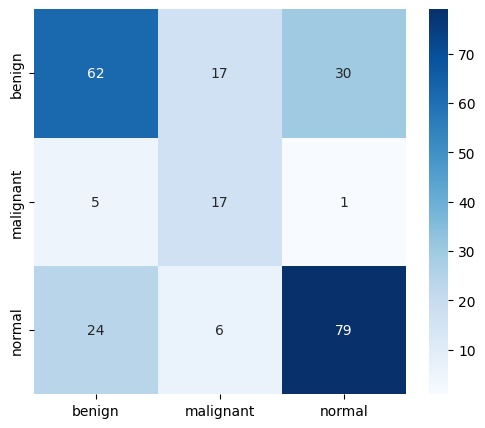

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_gen.labels,
    yticklabels=train_gen.labels
)

plt.savefig(
    f"{SAVE_DIR}/cm_cb_focal.png",
    bbox_inches="tight"
)

plt.show()

In [47]:
predictions = []

for i in range(len(test_gen)):

    X, y = test_gen[i]

    pred = model_cb.predict(
        X,
        verbose=0
    )

    for j in range(len(pred)):

        predictions.append({
            "true": np.argmax(y[j]),
            "pred": np.argmax(pred[j]),
            "confidence": float(np.max(pred[j]))
        })

pred_df_cb = pd.DataFrame(predictions)

pred_df_cb.to_csv(
    f"{SAVE_DIR}/predictions_cb_focal.csv",
    index=False
)

In [48]:
shap_values

array([[[[[-1.14453062e-04,  1.40492484e-04, -2.60393736e-05],
          [-1.66810874e-04,  1.77358219e-04, -1.05473400e-05],
          [-8.12829021e-05,  1.31344175e-04, -5.00613205e-05]],

         [[ 4.69138722e-05, -9.61613914e-05,  4.92475447e-05],
          [ 4.13948965e-06, -5.28164855e-06,  1.14215959e-06],
          [-2.15179243e-05,  5.90256459e-05, -3.75077507e-05]],

         [[ 1.30798493e-04, -2.12613289e-04,  8.18149128e-05],
          [ 2.18956600e-04, -2.37855667e-04,  1.88991380e-05],
          [-3.83633887e-05,  7.99158370e-05, -4.15524482e-05]],

         ...,

         [[-3.36219309e-05,  1.20383811e-04, -8.67617782e-05],
          [-1.00045858e-04,  1.02490711e-04, -2.44468970e-06],
          [-9.98583982e-06,  7.14880080e-05, -6.15021781e-05]],

         [[-6.42877421e-05,  6.76766431e-05, -3.38885206e-06],
          [-8.70659642e-05, -9.16135195e-06,  9.62275008e-05],
          [-4.85980527e-05,  5.40914916e-05, -5.49339211e-06]],

         [[ 1.15296280e-04, -1

In [49]:
import pickle

with open(
    f"{SAVE_DIR}/shap_values.pkl",
    "wb"
) as f:

    pickle.dump(
        shap_values,
        f
    )

In [50]:
with open(
    f"{SAVE_DIR}/shap_values.pkl",
    "rb"
) as f:

    shap_values = pickle.load(f)

In [51]:
plt.savefig(
    f"{SAVE_DIR}/lime_sample_1.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [52]:
plt.savefig(
    f"{SAVE_DIR}/lime_sample_2.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [53]:
plt.savefig(
    f"{SAVE_DIR}/lime_sample_3.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [54]:
model.save(
    f"{SAVE_DIR}/baseline.keras"
)

model_ws.save(
    f"{SAVE_DIR}/weighted_sampling.keras"
)

model_over.save(
    f"{SAVE_DIR}/oversampling.keras"
)

model_cb.save(
    f"{SAVE_DIR}/cb_focal.keras"
)

In [55]:
# ============================================================
# EVALUATE ALL MODELS + SAVE SUMMARY
# ============================================================

import pandas as pd
import numpy as np

from sklearn.metrics import (
    classification_report,
    accuracy_score
)

# ------------------------------------------------------------
# FUNCTION
# ------------------------------------------------------------

def evaluate_model(model, generator):

    y_true = []
    y_pred = []

    for i in range(len(generator)):

        X, y = generator[i]

        pred = model.predict(
            X,
            verbose=0
        )

        y_true.extend(
            np.argmax(y, axis=1)
        )

        y_pred.extend(
            np.argmax(pred, axis=1)
        )

    report = classification_report(
        y_true,
        y_pred,
        target_names=generator.labels,
        output_dict=True
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    return acc, report


# ------------------------------------------------------------
# BASELINE
# ------------------------------------------------------------

baseline_acc, report_baseline = evaluate_model(
    model,
    test_gen
)

baseline_recall = report_baseline["malignant"]["recall"]
baseline_f1 = report_baseline["malignant"]["f1-score"]


# ------------------------------------------------------------
# WEIGHTED SAMPLING
# ------------------------------------------------------------

ws_acc, report_ws = evaluate_model(
    model_ws,
    test_gen
)

ws_recall = report_ws["malignant"]["recall"]
ws_f1 = report_ws["malignant"]["f1-score"]


# ------------------------------------------------------------
# OVERSAMPLING
# ------------------------------------------------------------

over_acc, report_over = evaluate_model(
    model_over,
    test_gen
)

over_recall = report_over["malignant"]["recall"]
over_f1 = report_over["malignant"]["f1-score"]


# ------------------------------------------------------------
# CB FOCAL LOSS
# ------------------------------------------------------------

cb_acc, report_cb = evaluate_model(
    model_cb,
    test_gen
)

cb_recall = report_cb["malignant"]["recall"]
cb_f1 = report_cb["malignant"]["f1-score"]


# ------------------------------------------------------------
# SUMMARY TABLE
# ------------------------------------------------------------

summary = pd.DataFrame({

    "Model":[
        "Baseline",
        "Weighted Sampling",
        "Oversampling",
        "CB Focal Loss"
    ],

    "Accuracy":[
        baseline_acc,
        ws_acc,
        over_acc,
        cb_acc
    ],

    "Recall_Malignant":[
        baseline_recall,
        ws_recall,
        over_recall,
        cb_recall
    ],

    "F1_Malignant":[
        baseline_f1,
        ws_f1,
        over_f1,
        cb_f1
    ]
})

summary = summary.sort_values(
    "Recall_Malignant",
    ascending=False
)

display(summary)


# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

summary.to_csv(
    f"{SAVE_DIR}/experiment_summary.csv",
    index=False
)

print(
    f"Summary saved -> {SAVE_DIR}/experiment_summary.csv"
)

,Model,Accuracy,Recall_Malignant,F1_Malignant
3,CB Focal Loss,0.655602,0.739130,0.539683
1,Weighted Sampling,0.585062,0.652174,0.405405
0,Baseline,0.676349,0.521739,0.421053
2,Oversampling,0.585062,0.521739,0.352941


Summary saved -> /kaggle/working/xai_bone_cancer/experiment_summary.csv


In [56]:
# ============================================================
# SAVE MODELS
# ============================================================

model.save(
    f"{SAVE_DIR}/baseline.keras"
)

model_ws.save(
    f"{SAVE_DIR}/weighted_sampling.keras"
)

model_over.save(
    f"{SAVE_DIR}/oversampling.keras"
)

model_cb.save(
    f"{SAVE_DIR}/cb_focal_loss.keras"
)

print("All models saved.")

All models saved.


In [57]:
pd.DataFrame(history.history).to_csv(
    f"{SAVE_DIR}/baseline_history.csv",
    index=False
)

pd.DataFrame(history_ws.history).to_csv(
    f"{SAVE_DIR}/ws_history.csv",
    index=False
)

pd.DataFrame(history_over.history).to_csv(
    f"{SAVE_DIR}/oversampling_history.csv",
    index=False
)

pd.DataFrame(history_cb.history).to_csv(
    f"{SAVE_DIR}/cb_history.csv",
    index=False
)

print("All histories saved.")

All histories saved.


In [58]:
import os

for root, dirs, files in os.walk(SAVE_DIR):
    for f in files:
        print(os.path.join(root, f))

/kaggle/working/xai_bone_cancer/cb_focal_accuracy.png
/kaggle/working/xai_bone_cancer/history_cb_focal.csv
/kaggle/working/xai_bone_cancer/oversampling.keras
/kaggle/working/xai_bone_cancer/shap_values.pkl
/kaggle/working/xai_bone_cancer/experiment_summary.csv
/kaggle/working/xai_bone_cancer/lime_sample_3.png
/kaggle/working/xai_bone_cancer/baseline_history.csv
/kaggle/working/xai_bone_cancer/cb_focal.keras
/kaggle/working/xai_bone_cancer/oversampling_history.csv
/kaggle/working/xai_bone_cancer/lime_sample_2.png
/kaggle/working/xai_bone_cancer/lime_sample_1.png
/kaggle/working/xai_bone_cancer/cb_focal_loss.keras
/kaggle/working/xai_bone_cancer/weighted_sampling.keras
/kaggle/working/xai_bone_cancer/classification_report_cb_focal.csv
/kaggle/working/xai_bone_cancer/predictions_cb_focal.csv
/kaggle/working/xai_bone_cancer/cb_history.csv
/kaggle/working/xai_bone_cancer/ws_history.csv
/kaggle/working/xai_bone_cancer/model_cb_focal.keras
/kaggle/working/xai_bone_cancer/cm_cb_focal.png
/kagg